# Feature Engineering & Preprocessing
### Real Estate Machine · Graduation Project

Notebooks 01–04 and the business report produced a clean table and a set of findings. Here that table becomes a **matrix a model
can learn from**, and it has to be built in a way that does not lie to you.

---

## The one rule

> **Nothing learned from the test set may touch the training set.**

Every number a preprocessing step learns — a mean, a standard deviation, the average price of a zip
code — must be computed from training rows *only*. If a test row contributes even to a mean, your
test score is measuring a model that has already seen the answer.

This is called **data leakage**, and it is one of the most common failures in data science, because it is invisible: the code runs, the score goes up, and the model quietly fails in
production.

Here the notebook does not just avoid leakage — it **measures it**, twice, so the cost is known exactly.

---

## Outputs
| Output | Why it exists |
|---|---|
| `app/preprocessing.py` (already written — this notebook reads and tests it) | one source of truth shared by the notebook and the Streamlit app |
| `Models/preprocessor.pkl` | the fitted transformer, fitted on **train only** |
| `Models/scaler.pkl` | the numeric `StandardScaler` on its own  |
| `Data/split_indices.csv` | the exact train/test row assignment, so notebooks 06–09 reuse the same split |

## 1. Setup

Two imports here are unlike anything in Notebooks 01–04: we add `../app` to the import path and
pull the feature code in from a **module**, not from a cell.

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

DATA = Path("..") / "Data"
MODELS = Path("..") / "Models"
FIGS = Path("..") / "reports" / "figures"
MODELS.mkdir(exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

# Make app/preprocessing.py importable from this notebook.
sys.path.append(str((Path("..") / "app").resolve()))

df = pd.read_csv(DATA / "data_clean.csv", dtype={"zipcode": str})
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Clean data:", df.shape)
df.head(3)

Clean data: (4345, 21)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zipcode,was_renovated,effective_year,house_age,age_effective,price_per_sqft
0,2014-05-02,"313,000.000",3.000,1.500,1340,7912,1.500,0,0,3,1340,0,1955,NaN,Shoreline,98133,0,1955,59,59,233.582
1,2014-05-02,"2,384,000.000",5.000,2.500,3650,9050,2.000,0,4,5,3370,280,1921,NaN,Seattle,98119,0,1921,93,93,653.151
2,2014-05-02,"342,000.000",3.000,2.000,1930,11947,1.000,0,0,4,1930,0,1966,NaN,Kent,98042,0,1966,48,48,177.202


### Why the feature code lives in `app/preprocessing.py` and not in this notebook

In notebook 11 the Streamlit app must transform **one house typed into a form** in exactly the same way
the 3,476 training houses were transformed. If the transformer classes were defined in a notebook
cell, `joblib` could not reload them in the app — a pickle stores the *import path* of a class, not
its code. You would get `AttributeError: Can't get attribute 'SmoothedTargetEncoder'` at the worst
possible moment: during your live demo.

Putting the code in a module means the notebook and the app run **the same lines**. A preprocessing
bug is then a bug in both places, not a silent mismatch that shows up only as strange predictions
on stage.

Open `app/preprocessing.py` side by side with this notebook and read it as you go.

In [2]:
import preprocessing as P

print("REFERENCE_YEAR     :", P.REFERENCE_YEAR)
print("Never enter a model:", P.LEAKY_OR_DEAD)
print(f"Numeric features   : {len(P.NUMERIC_FEATURES)}")
print("Target-encoded     :", P.TARGET_ENCODE_FEATURES)

REFERENCE_YEAR     : 2014
Never enter a model: ['price', 'price_per_sqft', 'date', 'yr_built', 'yr_renovated', 'effective_year']
Numeric features   : 18
Target-encoded     : ['zipcode', 'city']


---
## 2. Redundancy check — before adding anything, remove what is already duplicated

Two columns that carry the *same* information are not harmless. For Linear Regression they are
fatal: if `a` and `b` are identical, then `3a + 0b`, `0a + 3b` and `1.5a + 1.5b` all fit the data
equally well. The model has no way to choose, so the coefficients — the thing you will stand up and
explain — become arbitrary.

Check for exact identities first, then near-identities.

In [3]:
# Identity 1: sqft_above is not a measurement, it is arithmetic.
resid = (df["sqft_above"] + df["sqft_basement"] - df["sqft_living"]).abs()
print("max |sqft_above + sqft_basement - sqft_living| =", resid.max())
print("-> sqft_above is fully determined by two other columns; it is dropped.")

max |sqft_above + sqft_basement - sqft_living| = 0
-> sqft_above is fully determined by two other columns; it is dropped.


In [4]:
# Identity 2: the two 'age since renewal' columns.
print("age_effective == years_since_reno for every row:",
      bool((df["age_effective"] == (P.REFERENCE_YEAR - df["effective_year"])).all()))

# This is why `age_effective` was removed from P.NUMERIC_FEATURES.
print("age_effective still in the model's feature list?",
      "age_effective" in P.NUMERIC_FEATURES)

age_effective == years_since_reno for every row: True
age_effective still in the model's feature list? False


**The key point:**

> `sqft_above = sqft_living - sqft_basement` holds exactly, with zero error, on all 4,345 rows. It
> is a derived column, not an independent measurement, so keeping all three would make the design
> matrix singular. I kept `sqft_living` and `sqft_basement` and dropped `sqft_above`.

The same logic removed the duplicated age column. Neither drop loses information — that is the test
of a *safe* drop, and it is different from dropping a column because it "looked unimportant".

---
## 3. Row-wise feature engineering

`engineer_features()` adds every feature that can be computed **from a single row**. Nothing in it
looks at another row, at a group average, or at `price`.

That property is what makes it safe to run *before* the train/test split — and it is the same
property that lets the Streamlit app call it on one house with no training data present.

In [5]:
before_cols = set(df.columns)
feat = P.engineer_features(df)
new_cols = [c for c in feat.columns if c not in before_cols]

print("Rows unchanged:", len(feat) == len(df))
print("New columns   :", new_cols)
feat[new_cols].head()

Rows unchanged: True
New columns   : ['years_since_reno', 'has_basement', 'basement_ratio', 'bath_per_bed', 'sqft_per_room', 'log_sqft_living', 'log_sqft_lot']


,years_since_reno,has_basement,basement_ratio,bath_per_bed,sqft_per_room,log_sqft_living,log_sqft_lot
0,59.000,0,0.000,0.500,297.778,7.201,8.976
1,93.000,1,0.077,0.500,486.667,8.203,9.111
2,48.000,0,0.000,0.667,386.000,7.566,9.388
3,51.000,1,0.500,0.750,380.952,7.601,8.991
4,38.000,1,0.412,0.625,298.462,7.571,9.259


### What each engineered feature is for

| Feature | Definition | Why a model needs it |
|---|---|---|
| `house_age` | `2014 - yr_built` | age is what buyers react to; a raw year is a meaningless number on a ruler |
| `years_since_reno` | years since renovation, else full age | an honest reading of "how long since this house was renewed" |
| `was_renovated` | 0/1 | only ~4.9% of rows; the flag lets the model treat them as a group |
| `has_basement` / `basement_ratio` | `sqft_basement > 0` · basement share of living area | the business report showed below-grade space is worth less per sqft than above-grade |
| `bath_per_bed` | bathrooms ÷ bedrooms | layout **quality**: 4 beds / 1 bath and 4 beds / 3 baths are different products |
| `sqft_per_room` | living area ÷ (beds + baths) | spacious vs. chopped-up at the same total size |
| `log_sqft_living`, `log_sqft_lot` | `log1p(...)` | notebook 03 showed both are strongly right-skewed; logging them makes the relationship with `log(price)` roughly linear |

Two details worth understanding rather than skimming:

**A never-renovated house gets `years_since_reno = house_age`, not 0 and not `NaN`.** Zero would
claim it was renewed this year — the opposite of the truth. `NaN` would force an imputation
decision later. Its full age is the honest answer to the question the feature is asking.

**Division produces `NaN` when the denominator is 0** (a 0-bedroom studio). Those are filled with
the neutral value inside `engineer_features`, not dropped — notebook 02 already decided which rows
deserve to be removed, and "this feature was awkward to compute" is not a data-quality reason.

In [6]:
# Sanity: no NaN, no infinities in anything the model will see.
check = feat[P.NUMERIC_FEATURES]
print("NaNs      :", int(check.isna().sum().sum()))
print("Infinities:", int(np.isinf(check.to_numpy(dtype=float)).sum()))
check.describe().T[["min", "50%", "max"]]

NaNs      : 0
Infinities: 0


,min,50%,max
bedrooms,1.000,3.000,9.000
bathrooms,0.750,2.250,8.000
sqft_living,370.000,"1,970.000","13,540.000"
sqft_lot,638.000,"7,666.000","1,074,218.000"
floors,1.000,1.500,3.500
waterfront,0.000,0.000,1.000
view,0.000,0.000,4.000
condition,1.000,3.000,5.000
sqft_basement,0.000,0.000,"4,820.000"
house_age,0.000,38.000,114.000


---
## 4. What must never enter the model

`P.LEAKY_OR_DEAD` lists the columns that are excluded on purpose. The important one is
`price_per_sqft`.

`price_per_sqft = price / sqft_living`. It was the hero of the business report — and it is
**forbidden** as a model input, because it contains the target. Multiply it by `sqft_living` and you
have the answer. A model given this feature does not predict prices; it divides and multiplies.

Prove it to yourself. A number you produced is worth ten warnings you read.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# log(price) = log(price_per_sqft) + log(sqft_living), exactly. So a linear model
# given those two columns only has to find the coefficients (1, 1).
y_demo = np.log(feat["price"])
X_demo = pd.DataFrame({"log_pps": np.log(feat["price_per_sqft"]),
                       "log_sqft": np.log(feat["sqft_living"])})
a, b, ya, yb = train_test_split(X_demo, y_demo, test_size=0.2, random_state=42)

leaky = LinearRegression().fit(a, ya)
print(f"Coefficients found: {leaky.coef_.round(4)}   (the true answer is [1, 1])")
print(f"R2 on unseen data : {r2_score(yb, leaky.predict(b)):.6f}")
print("That is not a model. It is a rearranged equation.")

Coefficients found: [1. 1.]   (the true answer is [1, 1])
R2 on unseen data : 1.000000
That is not a model. It is a rearranged equation.


Also excluded:

- `date` — the data covers only May–July 2014. Ten weeks contains no seasonal signal, and a model
  that learns "July is expensive" from ten weeks has learned noise.
- `yr_built`, `yr_renovated`, `effective_year` — superseded by the age features above.

---
## 5. The split — and it happens *now*

Everything up to this point was row-wise, so its position relative to the split does not matter.
Everything after this point **learns from the data**, so it must only ever see training rows.

80 / 20, `random_state=42` so notebooks 06–09 reproduce it exactly. The split indices get written to disk
for the same reason: "I re-ran it and got the same split" is a claim you should be able to make.

In [8]:
X = feat[P.ALL_FEATURES].copy()
y = np.log1p(feat["price"])          # notebook 03 showed log(price) is near-normal

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} rows   Test: {X_test.shape[0]:,} rows")
print(f"Features: {X_train.shape[1]}  ({len(P.NUMERIC_FEATURES)} numeric "
      f"+ {len(P.TARGET_ENCODE_FEATURES)} categorical)")

split = pd.Series("train", index=feat.index, name="split")
split.loc[X_test.index] = "test"
split.to_frame().to_csv(DATA / "split_indices.csv", index_label="row")
print("Saved ->", DATA / "split_indices.csv")

Train: 3,476 rows   Test: 869 rows
Features: 20  (18 numeric + 2 categorical)
Saved -> ..\Data\split_indices.csv


### Why `log(price)` and not `price`

Notebook 03 established that `price` is strongly right-skewed and `log(price)` is close to normal. Two
consequences:

1. Linear models assume roughly constant error variance. On raw prices a \$100k miss on a \$300k
   house and on a \$3M house count the same; on log prices the model is penalised on *percentage*
   error, which is how a business actually thinks about valuation.
2. The handful of very expensive houses stop dominating the fit.

**The trap:** every error you report has to be converted back with `np.expm1()` first. An RMSE of
0.16 in log space is not \$0.16 and it is not 16% — do the conversion, always. This appears again in notebook 08
.


---
## 6. Target encoding — location, without 121 dummy columns

`zipcode` has 77 levels and `city` has 44. One-hot encoding gives 121 mostly-empty columns, and any
zip code absent from the training set becomes an all-zero row the model cannot reason about.

**Target encoding** replaces each category with the mean target of that category — the average
`log(price)` of houses in that zip code. One column, and it carries exactly the signal notebook 04 found
was strongest after size: *where the house is*.

It is also the single easiest way to leak the target into your features. Two safeguards are needed.

In [9]:
counts = X_train["zipcode"].value_counts()
print(f"Zip codes in training data : {counts.size}")
print(f"Median sales per zip code  : {counts.median():.0f}")
print(f"Zip codes with < 20 sales  : {(counts < 20).sum()}")
print(f"Smallest zip code          : {counts.min()} sale(s)")

Zip codes in training data : 77
Median sales per zip code  : 46
Zip codes with < 20 sales  : 15
Smallest zip code          : 1 sale(s)


### Safeguard 1 — smoothing, which is credibility weighting

A zip code with 142 sales gives a trustworthy average. A zip code with 3 sales gives an average that
is mostly luck. Using both at face value tells the model to trust them equally.

So each category mean is pulled toward the global mean:

$$\text{encoded} = Z \cdot \bar{y}_{\text{category}} + (1 - Z)\cdot \bar{y}_{\text{global}},
\qquad Z = \frac{n}{n + m}$$

You have seen this before. It is **credibility theory** from actuarial ratemaking, where a small
class's own experience is blended with the portfolio average using $Z = n/(n+k)$. Same problem
(thin cells), same solution.

### Safeguard 2 — out-of-fold encoding on the training set

If a row's own price helps compute the average that becomes that row's feature, the feature partly
*is* the answer. Training performance inflates, the model over-trusts the column, and test
performance drops.

So `SmoothedTargetEncoder.fit_transform` encodes each training row using a mapping built from the
**other** folds only. `transform` (used for the test set, and for the app) uses the full-training
mapping, which is correct — test rows contributed nothing to it.

In [10]:
enc = P.SmoothedTargetEncoder(cols=["zipcode"], smoothing=20)
oof = enc.fit_transform(X_train[["zipcode"]], y_train).ravel()      # out-of-fold
infold = enc.transform(X_train[["zipcode"]]).ravel()                # uses own row

comp = pd.DataFrame({"zipcode": X_train["zipcode"].values,
                     "oof": oof, "in_fold": infold})
summary = (comp.groupby("zipcode")
                .agg(n=("oof", "size"),
                     oof_mean=("oof", "mean"),
                     infold_mean=("in_fold", "mean"))
                .assign(gap=lambda d: (d.infold_mean - d.oof_mean).abs())
                .sort_values("n"))
print("The two encodings diverge most where the sample is thinnest:")
summary.head(8)

The two encodings diverge most where the sample is thinnest:


,n,oof_mean,infold_mean,gap
zipcode,,,,
98068,1,13.074,13.079,0.005
98354,1,13.077,13.056,0.021
98288,2,13.077,12.964,0.113
98050,2,13.082,13.087,0.005
98051,5,13.080,13.077,0.003
98010,6,13.032,13.007,0.025
98047,6,12.939,12.900,0.039
98039,9,13.426,13.543,0.117


---
## 7. Choosing the smoothing constant `m` — by cross-validation, not by taste

`m` is the number of sales a category needs before its own average is trusted half as much as the
global one — `m = 20` is the module default. That number should be **chosen and defended**, not inherited from a default, so it is re-derived here.

Rules:

- Cross-validate on the **training set only**. The test set does not vote on hyperparameters — if it
  does, it stops being a test set.
- Use the **one-standard-error rule**: among values within one standard error of the best score,
  take the most conservative (largest `m`). Differences smaller than the noise are not differences,
  and the more smoothed model is the one that survives contact with a thin zip code.

In [11]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for m in [0, 2, 5, 10, 20, 50]:
    pipe = Pipeline([("pre", P.build_preprocessor(smoothing=m)), ("model", Ridge(alpha=1.0))])
    scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring="r2")
    rows.append({"m": m, "cv_r2": scores.mean(), "std": scores.std(),
                 "se": scores.std() / np.sqrt(len(scores))})

cv = pd.DataFrame(rows)
best = cv.loc[cv.cv_r2.idxmax()]
threshold = best.cv_r2 - best.se
cv["within_1se"] = cv.cv_r2 >= threshold
print(f"Best m = {best.m:.0f} (CV R2 = {best.cv_r2:.4f}), one-SE threshold = {threshold:.4f}")
cv

Best m = 2 (CV R2 = 0.8381), one-SE threshold = 0.8302


,m,cv_r2,std,se,within_1se
0,0,0.837,0.017,0.008,True
1,2,0.838,0.018,0.008,True
2,5,0.837,0.018,0.008,True
3,10,0.834,0.018,0.008,True
4,20,0.830,0.017,0.008,False
5,50,0.822,0.017,0.008,False


Chosen smoothing m = 10


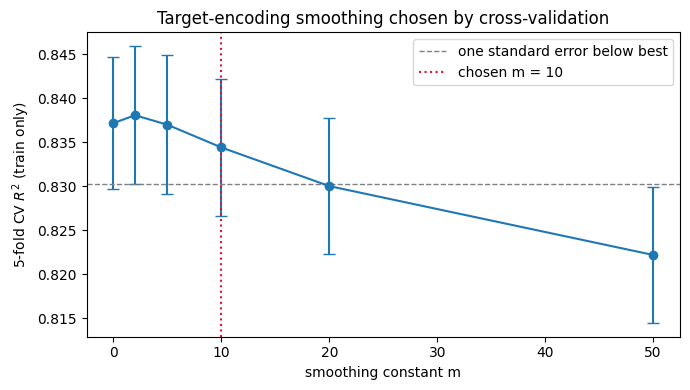

In [12]:
chosen_m = int(cv.loc[cv.within_1se, "m"].max())     # most smoothed model within one SE
print("Chosen smoothing m =", chosen_m)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(cv["m"], cv["cv_r2"], yerr=cv["se"], marker="o", capsize=4)
ax.axhline(threshold, ls="--", c="grey", lw=1, label="one standard error below best")
ax.axvline(chosen_m, ls=":", c="crimson", lw=1.5, label=f"chosen m = {chosen_m}")
ax.set_xlabel("smoothing constant m"); ax.set_ylabel("5-fold CV $R^2$ (train only)")
ax.set_title("Target-encoding smoothing chosen by cross-validation")
ax.legend(); fig.tight_layout()
fig.savefig(FIGS / "05_smoothing_choice.png", dpi=150)
plt.show()

Note what the chart is likely to show: the differences across `m` are **small relative to the fold
noise**. That is a finding, not a disappointment, and you should say it plainly:

> With a median of roughly 46 sales per zip code in the training set, the encoding is well estimated
> almost everywhere, so the model is barely sensitive to `m`. I chose the most smoothed value within
> one standard error of the best, because it costs nothing measurable and it protects the 15 zip
> codes with fewer than 20 sales — one of which has a single sale.

That sentence is worth more than a chart with a dramatic peak, because it shows the error bars were read.

---
## 8. Measuring leakage instead of just warning about it

Three fits of the same Ridge model, differing only in **how the preprocessor was fitted**:

| | How the encoder was fitted | Legitimate? |
|---|---|---|
| A | train only, out-of-fold | ✅ correct |
| B | on **all** data, train + test together | ❌ test prices leak into training features |
| C | train only, but each row encoded with its own price included | ❌ in-fold leakage |

In [13]:
def fit_and_score(Z_train, Z_test, label):
    model = Ridge(alpha=1.0).fit(Z_train, y_train)
    tr = r2_score(y_train, model.predict(Z_train))
    te = r2_score(y_test, model.predict(Z_test))
    print(f"{label:<34} train R2 = {tr:.4f}   test R2 = {te:.4f}   gap = {tr - te:+.4f}")
    return te

# A — correct
preA = P.build_preprocessor(smoothing=chosen_m)
ZA_tr, ZA_te = preA.fit_transform(X_train, y_train), preA.transform(X_test)
rA = fit_and_score(ZA_tr, ZA_te, "A  correct (train-only, OOF)")

# B — encoder sees the test set
preB = P.build_preprocessor(smoothing=chosen_m)
preB.fit(X, y)                                    # <-- the mistake
rB = fit_and_score(preB.transform(X_train), preB.transform(X_test), "B  fitted on train + test")

# C — train-only, but in-fold
preC = P.build_preprocessor(smoothing=chosen_m)
preC.fit(X_train, y_train)                        # fit(), so no out-of-fold protection
rC = fit_and_score(preC.transform(X_train), preC.transform(X_test), "C  in-fold encoding")

print(f"\nApparent gain from leaking the test set: {rB - rA:+.4f} R2")

A  correct (train-only, OOF)       train R2 = 0.8393   test R2 = 0.8307   gap = +0.0086
B  fitted on train + test          train R2 = 0.8461   test R2 = 0.8374   gap = +0.0087
C  in-fold encoding                train R2 = 0.8464   test R2 = 0.8332   gap = +0.0133

Apparent gain from leaking the test set: +0.0067 R2


### Read the result honestly

The inflation here is **small** — well under one point of $R^2$. Do not overstate it. The reason is
in the numbers from section 6: with a median of ~46 sales per zip code, one leaked row barely moves
a category average.

The size of leakage scales with **category cardinality**. Take it to the limit — a category with one
row per house, which is what an ID column, an address, or a listing reference is.

In [14]:
# A near-unique key: every category has exactly one row.
key_tr = pd.DataFrame({"listing_id": [f"L{i}" for i in range(len(X_train))]}, index=X_train.index)
key_te = pd.DataFrame({"listing_id": [f"L{i}" for i in range(len(X_train), len(X_train) + len(X_test))]},
                      index=X_test.index)

bad = P.SmoothedTargetEncoder(cols=["listing_id"], smoothing=0)
Zb_tr = bad.fit(key_tr, y_train).transform(key_tr)     # fit(): each row encodes its own price
Zb_te = bad.transform(key_te)

mdl = Ridge(alpha=1.0).fit(Zb_tr, y_train)
print(f"train R2 = {r2_score(y_train, mdl.predict(Zb_tr)):.4f}   "
      f"test R2 = {r2_score(y_test, mdl.predict(Zb_te)):.4f}")
print("Perfect on training data, worthless on new data: it memorised, it did not learn.")

train R2 = 1.0000   test R2 = -0.0014
Perfect on training data, worthless on new data: it memorised, it did not learn.


**In short:**

> Leakage is not one bug, it is a family. I measured it two ways: refitting the encoder on train +
> test gained under a point of $R^2$ here, because zip codes have ~46 sales each and one row barely
> moves an average. But the same code on a near-unique key gives training $R^2$ of 1.000 and
> test $R^2$ of 0.000 — so the magnitude depends on cardinality, and the only safe policy is to fit
> every statistic on training rows alone.

One more, on scaling specifically: fitting `StandardScaler` before the split leaks the test mean and
standard deviation. The effect is usually tiny — but "small" is not "correct", and the policy matters more than the luck of one run.

---
## 9. Fit the final preprocessor and save it

`preA` above is already fitted correctly on the training set. Save it, plus the numeric scaler on
its own , plus the feature order — the app must feed columns in the
same order the model was trained on.

In [15]:
joblib.dump(preA, MODELS / "preprocessor.pkl")
joblib.dump(preA.named_transformers_["num"], MODELS / "scaler.pkl")
joblib.dump({"all_features": P.ALL_FEATURES,
             "numeric": P.NUMERIC_FEATURES,
             "target_encoded": P.TARGET_ENCODE_FEATURES,
             "output_order": P.feature_names(preA),
             "smoothing": chosen_m,
             "target": "log1p(price)",
             "random_state": 42},
            MODELS / "feature_config.pkl")

for f in sorted(MODELS.glob("*.pkl")):
    print(f"{f.name:<24} {f.stat().st_size / 1024:6.1f} KB")

classifier.pkl              2.2 KB
classifier_config.pkl       0.5 KB
cluster_config.pkl          0.3 KB
cluster_pipeline.pkl       15.5 KB
cluster_scaler.pkl          1.1 KB
feature_config.pkl          0.5 KB
kmeans.pkl                 14.6 KB
preprocessor.pkl            5.5 KB
reference_stats.pkl         2.5 KB
regression_baseline.pkl     5.9 KB
regression_config.pkl       0.6 KB
regressor.pkl             757.0 KB
regressor_config.pkl        1.1 KB
scaler.pkl                  1.5 KB
shap_background.pkl        31.8 KB


In [16]:
Z_train = pd.DataFrame(ZA_tr, columns=P.feature_names(preA), index=X_train.index)
Z_test = pd.DataFrame(ZA_te, columns=P.feature_names(preA), index=X_test.index)

print("Design matrix:", Z_train.shape, "train /", Z_test.shape, "test")
print("\nScaled on TRAIN (means ~0, sd ~1):")
print(Z_train.agg(["mean", "std"]).T.head(6))
print("\nSame columns on TEST — NOT exactly 0/1, and that is the proof the scaler never saw them:")
print(Z_test.agg(["mean", "std"]).T.head(6))

Design matrix: (3476, 20) train / (869, 20) test

Scaled on TRAIN (means ~0, sd ~1):
              mean   std
bedrooms    -0.000 1.000
bathrooms    0.000 1.000
sqft_living -0.000 1.000
sqft_lot     0.000 1.000
floors      -0.000 1.000
waterfront  -0.000 1.000

Same columns on TEST — NOT exactly 0/1, and that is the proof the scaler never saw them:
              mean   std
bedrooms     0.020 1.016
bathrooms    0.041 1.077
sqft_living  0.051 1.079
sqft_lot     0.062 1.100
floors      -0.016 0.974
waterfront   0.041 1.233


That last output is the cheapest leakage test that exists. If the test columns also had mean exactly
0 and sd exactly 1, the scaler had been fitted on the test set. They should be *close* to 0 and 1 —
because train and test come from the same population — but not equal.

---
## 10. The app contract — one house, end to end

The Streamlit app will receive one house from a form. Simulate it now, while there is time to fix
it, instead of in notebook 11 when there is not.

In [17]:
one_house = pd.DataFrame([{
    "bedrooms": 3, "bathrooms": 2.0, "sqft_living": 1800, "sqft_lot": 7500,
    "floors": 1.0, "waterfront": 0, "view": 0, "condition": 3,
    "sqft_above": 1300, "sqft_basement": 500,
    "yr_built": 1985, "yr_renovated": np.nan,
    "city": "Seattle", "zipcode": "98115",
}])

row = P.engineer_features(one_house)
z = preA.transform(row[P.ALL_FEATURES])
print("Transformed shape:", z.shape, "-> must match", (1, Z_train.shape[1]))
pd.DataFrame(z, columns=P.feature_names(preA)).T.rename(columns={0: "scaled value"}).head(10)

Transformed shape: (1, 20) -> must match (1, 20)


,scaled value
bedrooms,-0.439
bathrooms,-0.202
sqft_living,-0.346
sqft_lot,-0.195
floors,-0.949
waterfront,-0.078
view,-0.306
condition,-0.666
sqft_basement,0.412
house_age,-0.486


In [18]:
# And an unseen zip code must not crash — it falls back to the global training mean.
odd = one_house.copy()
odd.loc[0, "zipcode"] = "99999"
odd.loc[0, "city"] = "Atlantis"
z_odd = preA.transform(P.engineer_features(odd)[P.ALL_FEATURES])
print("Unseen category handled, shape:", z_odd.shape, "| any NaN:", bool(np.isnan(z_odd).any()))

Unseen category handled, shape: (1, 20) | any NaN: False


---
## 11. A baseline number to carry into notebook 08

Not the final model — just a signpost, so that in notebook 08 you can tell whether Random Forest and
Gradient Boosting are actually earning their complexity.

In [19]:
from sklearn.metrics import mean_absolute_error

baseline = Ridge(alpha=1.0).fit(Z_train, y_train)
pred_log = baseline.predict(Z_test)

pred_dollars = np.expm1(pred_log)          # back to dollars BEFORE reporting anything
true_dollars = np.expm1(y_test)
ape = np.abs(pred_dollars - true_dollars) / true_dollars

print(f"Ridge baseline (log target)")
print(f"  R2                        : {r2_score(y_test, pred_log):.4f}")
print(f"  MAE in log space          : {mean_absolute_error(y_test, pred_log):.4f}   <- not dollars")
print(f"  Median abs % error (MedAPE): {np.median(ape) * 100:.1f}%")
print(f"  MAE in dollars            : ${np.abs(pred_dollars - true_dollars).mean():,.0f}")

Ridge baseline (log target)
  R2                        : 0.8307
  MAE in log space          : 0.1605   <- not dollars
  Median abs % error (MedAPE): 12.6%
  MAE in dollars            : $101,900


Remember which of those numbers a manager understands. It is the percentage one. `R²` is for the
appendix; **MedAPE** goes on the slide. Notebook 08 sets this against published AVM benchmarks.

---
## 12. Outputs
**Produced**

- `Models/preprocessor.pkl` — fitted on training rows only
- `Models/scaler.pkl`, `Models/feature_config.pkl`
- `Data/split_indices.csv` — the split notebooks 06–09 must reuse
- `reports/figures/05_smoothing_choice.png`

**Next:** clustering. It uses the same split file, and deliberately *not* the
target-encoded location features — the reason is in `06_clustering.ipynb`.